In [2]:
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [1]:
import os

print(os.listdir('/kaggle/input'))

['datasets']


In [3]:
print(os.listdir('/kaggle/input/datasets'))

['suprithamathi']


In [7]:
print(os.listdir('/kaggle/input/datasets'))

['suprithamathi', 'paultimothymooney']


In [8]:
print(os.listdir('/kaggle/input/datasets/paultimothymooney'))

['chest-xray-pneumonia']


In [9]:
print(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia'))

['chest_xray']


In [10]:
print(os.listdir('/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray'))

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [11]:
import numpy as np
import os
import cv2

classes = {
    'NORMAL': 0,
    'PNEUMONIA': 1
}

X = []
Y = []

base_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"

for cls, label in classes.items():
    
    folder_path = os.path.join(base_path, cls)
    
    for filename in os.listdir(folder_path):
        
        img_path = os.path.join(folder_path, filename)
        
        img = cv2.imread(img_path, 0)
        
        if img is not None:
            
            img = cv2.resize(img, (200, 200))
            
            X.append(img.flatten() / 255.0)
            
            Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (5216, 40000)
Y shape: (5216,)


In [ ]:
# Split the dataset into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(
    X,
    Y,
    random_state=10,
    test_size=0.2
)

# Use only 80% of the training data
xtrain_small, _, ytrain_small, _ = train_test_split(
    xtrain,
    ytrain,
    train_size=0.8,
    random_state=10
)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain_small)

pca_test = pca.transform(xtest)

# Train Support Vector Classifier
sv = SVC(kernel='linear')

sv.fit(pca_train, ytrain_small)

# Evaluate the model
train_score = sv.score(pca_train, ytrain_small)

test_score = sv.score(pca_test, ytest)

print("Training Score:", train_score)

print("Testing Score:", test_score)

In [40]:
# Display sample images and predictions
def display_samples(folder, title, num_samples=9):
    plt.figure(figsize=(12, 8))
    c = 1
    for i, filename in enumerate(os.listdir(folder)[:num_samples]):
        img = cv2.imread(os.path.join(folder, filename), 0)
        img = cv2.resize(img, (200, 200)).flatten() / 255.0  # Preprocess the test image
        prediction = sv.predict(pca.transform([img]))  # Predict using the trained SVM
        
        plt.subplot(3, 3, c)
        plt.title(dec[prediction[0]])  # Map prediction to human-readable label
        plt.imshow(img.reshape(200, 200), cmap='gray')  # Display the image
        plt.axis('off')
        c += 1
    plt.suptitle(title)
    plt.show()

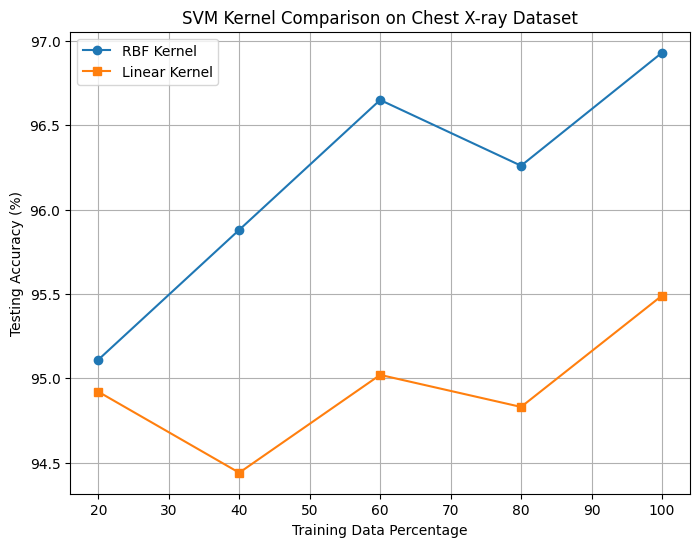

In [44]:
import matplotlib.pyplot as plt

training_sizes = [20, 40, 60, 80, 100]

rbf_accuracies = [
    95.11,
    95.88,
    96.65,
    96.26,
    96.93
]

linear_accuracies = [
    94.92,
    94.44,
    95.02,
    94.83,
    95.49
]

plt.figure(figsize=(8,6))

plt.plot(training_sizes, rbf_accuracies, marker='o', label='RBF Kernel')

plt.plot(training_sizes, linear_accuracies, marker='s', label='Linear Kernel')

plt.xlabel('Training Data Percentage')

plt.ylabel('Testing Accuracy (%)')

plt.title('SVM Kernel Comparison on Chest X-ray Dataset')

plt.legend()

plt.grid(True)

plt.show()

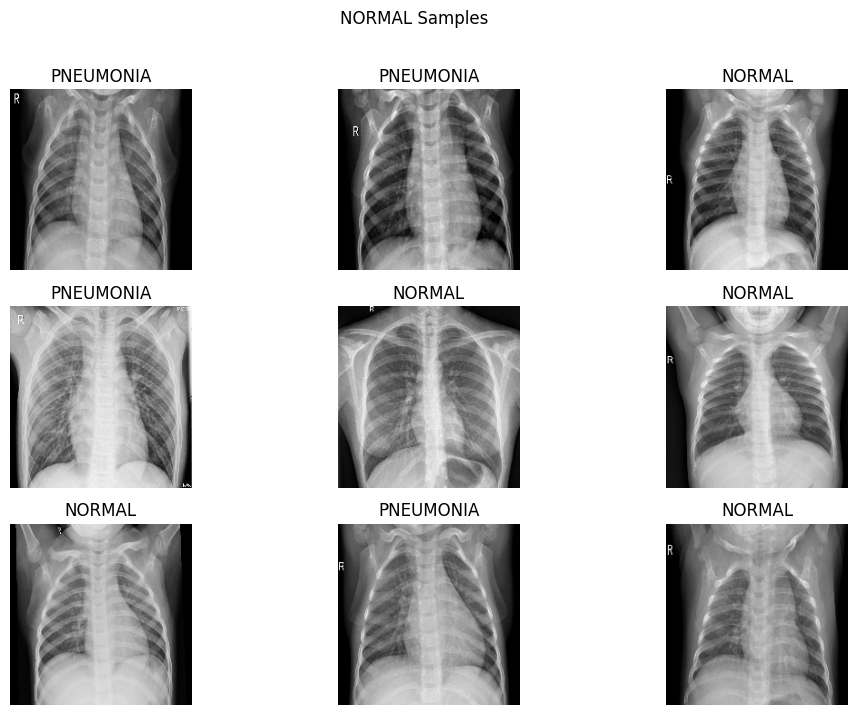

In [42]:
dec = {
    0: 'NORMAL',
    1: 'PNEUMONIA'
}

folder_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/NORMAL"

display_samples(folder_path, "NORMAL Samples")

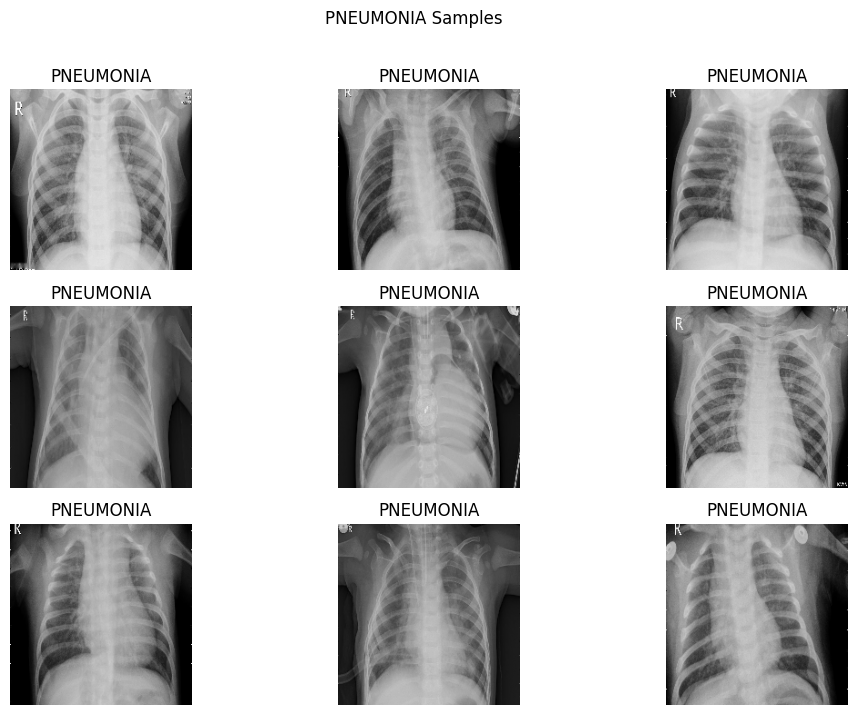

In [43]:
folder_path = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test/PNEUMONIA"

display_samples(folder_path, "PNEUMONIA Samples")

In [41]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Predictions
ypred = sv.predict(pca_test)

# Accuracy
accuracy = accuracy_score(ytest, ypred)

# F1 Score
f1 = f1_score(ytest, ypred)

# Confusion Matrix
cm = confusion_matrix(ytest, ypred)

# Sensitivity (Recall)
sensitivity = cm[1,1] / (cm[1,1] + cm[1,0])

# Specificity
specificity = cm[0,0] / (cm[0,0] + cm[0,1])

print("Accuracy:", accuracy)

print("F1 Score:", f1)

print("Sensitivity:", sensitivity)

print("Specificity:", specificity)

Accuracy: 0.9693486590038314
F1 Score: 0.9791395045632334
Sensitivity: 0.9842726081258192
Specificity: 0.9288256227758007


In [37]:
import pandas as pd

# Define class labels
dec = {
    0: 'NORMAL',
    1: 'PNEUMONIA'
}

# Count the occurrences of each class
class_counts = {
    dec[label]: np.sum(Y == label)
    for label in classes.values()
}

# Create table
table_data = {
    'Index': range(1, len(classes) + 1),
    'Class Type': list(class_counts.keys()),
    'Count': list(class_counts.values())
}

class_table = pd.DataFrame(table_data)

# Style the table
styled_table = class_table.style.set_properties(
    **{
        'border': '3px solid black',
        'text-align': 'center'
    }
)

# Display table
print("\033[1mChest X-ray Class Counts:\033[0m")

display(styled_table)

Chest X-ray Class Counts:


,Index,Class Type,Count
0,1,NORMAL,1341
1,2,PNEUMONIA,3875


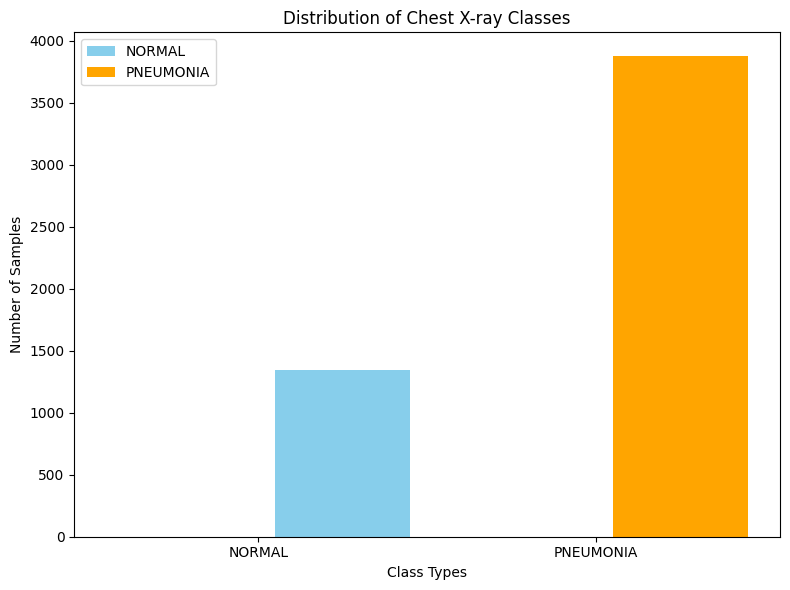

In [39]:
# Create histogram of class distribution

class_labels = [dec[label] for label in Y]

colors = ['skyblue', 'orange']

plt.figure(figsize=(8, 6))

for label, color in zip(classes.values(), colors):

    plt.hist(
        np.array(class_labels)[Y == label],
        bins=len(classes),
        align='mid',
        rwidth=0.8,
        color=color,
        label=dec[label]
    )

plt.xlabel('Class Types')

plt.ylabel('Number of Samples')

plt.title('Distribution of Chest X-ray Classes')

plt.xticks(
    range(len(classes)),
    list(classes.keys()),
    rotation=0
)

plt.legend()

plt.tight_layout()

plt.show()